# 02 — Model Training & Comparison
Train Random Forest, XGBoost, and LSTM. Compare on RMSE / MAE / R².

## 1. Imports & config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, os, pickle
warnings.filterwarnings("ignore")

PROC_DIR    = "D:/Minor Project/processed_data"
MODELS_DIR  = "D:/Minor Project/models"
RESULTS_DIR = "D:/Minor Project/results"

for d in [MODELS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

FEATURE_COLS = [
    "hour_slot","dayofweek","month","is_weekend","season",
    "GC_lag_1","GC_lag_2","GC_lag_48","GC_lag_336",
    "GC_roll_3d","GC_roll_7d",
    "generator_kwp",
]
TARGET = "GC"


## 2. Load data & temporal train/test split

In [2]:
df = pd.read_csv(os.path.join(PROC_DIR, "final_dataset.csv"), parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# 👉 create lag & rolling features here

# THEN drop NaNs
df = df.dropna(subset=FEATURE_COLS + [TARGET]).reset_index(drop=True)

# Time-based split
cutoff = df["timestamp"].max() - pd.DateOffset(months=3)

train  = df[df["timestamp"] <= cutoff]
test   = df[df["timestamp"] >  cutoff]

present = [c for c in FEATURE_COLS if c in df.columns]

X_train, y_train = train[present].values, train[TARGET].values
X_test,  y_test  = test[present].values,  test[TARGET].values

In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metrics(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:20s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return {"Model": name, "RMSE": round(rmse,4), "MAE": round(mae,4), "R2": round(r2,4)}

all_results = []
all_preds   = {}


## 3. Model 1 — Random Forest (baseline)

In [5]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=30,     # optimized
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

all_results.append(metrics(y_test, y_pred_rf, "Random Forest"))
all_preds["Random Forest"] = y_pred_rf

with open(os.path.join(MODELS_DIR, "random_forest.pkl"), "wb") as f:
    pickle.dump(rf, f)

print("✅ Model saved.")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:  8.8min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


Random Forest         RMSE=0.2664  MAE=0.1418  R²=0.5047
✅ Model saved.


[Parallel(n_jobs=16)]: Done  30 out of  30 | elapsed:    0.3s finished


In [8]:
import os
import matplotlib.pyplot as plt

os.makedirs(RESULTS_DIR, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")

CHART_COLORS = {
    "Random Forest": "#2E86DE",
    "XGBoost": "#6C5CE7",
    "LSTM": "#E17055",
    "Actual": "#222222"
}

def final_plot(save_name):
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, save_name), dpi=200, bbox_inches="tight")
    plt.show()

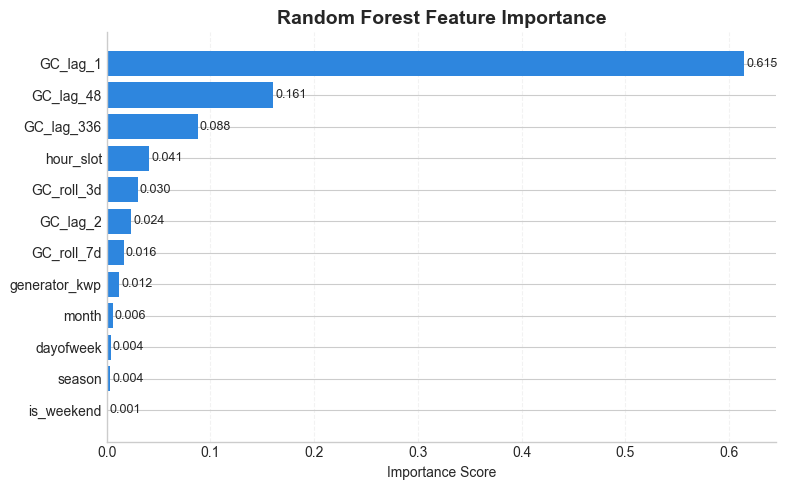

In [9]:
# Better RF feature importance
imp = pd.Series(rf.feature_importances_, index=present).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(imp.index[::-1], imp.values[::-1], color=CHART_COLORS["Random Forest"])
ax.set_title("Random Forest Feature Importance", fontsize=14, weight="bold")
ax.set_xlabel("Importance Score")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25)

for i, v in enumerate(imp.values[::-1]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

final_plot("rf_feature_importance.png")

## 4. Model 2 — XGBoost

In [10]:
import torch
print(torch.cuda.is_available())

True


In [11]:
from xgboost import XGBRegressor

# Using last 10% of train as validation for early stopping
val_cut  = int(len(X_train) * 0.9)
X_tr, X_val = X_train[:val_cut], X_train[val_cut:]
y_tr, y_val = y_train[:val_cut], y_train[val_cut:]

xgb = XGBRegressor(
    n_estimators=1000, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    early_stopping_rounds=50, eval_metric="rmse",
    random_state=42,tree_method="hist",
    device="cuda"
)
xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=50)

y_pred_xgb = xgb.predict(X_test)
all_results.append(metrics(y_test, y_pred_xgb, "XGBoost"))
all_preds["XGBoost"] = y_pred_xgb

with open(os.path.join(MODELS_DIR, "xgboost.pkl"), "wb") as f:
    pickle.dump(xgb, f)

print("✅ Model saved.")


[0]	validation_0-rmse:0.35369
[50]	validation_0-rmse:0.24591
[100]	validation_0-rmse:0.24418
[150]	validation_0-rmse:0.24345
[200]	validation_0-rmse:0.24303
[250]	validation_0-rmse:0.24271
[300]	validation_0-rmse:0.24251
[350]	validation_0-rmse:0.24242
[400]	validation_0-rmse:0.24232
[450]	validation_0-rmse:0.24219
[500]	validation_0-rmse:0.24222
[524]	validation_0-rmse:0.24218
XGBoost               RMSE=0.2632  MAE=0.1429  R²=0.5166
✅ Model saved.


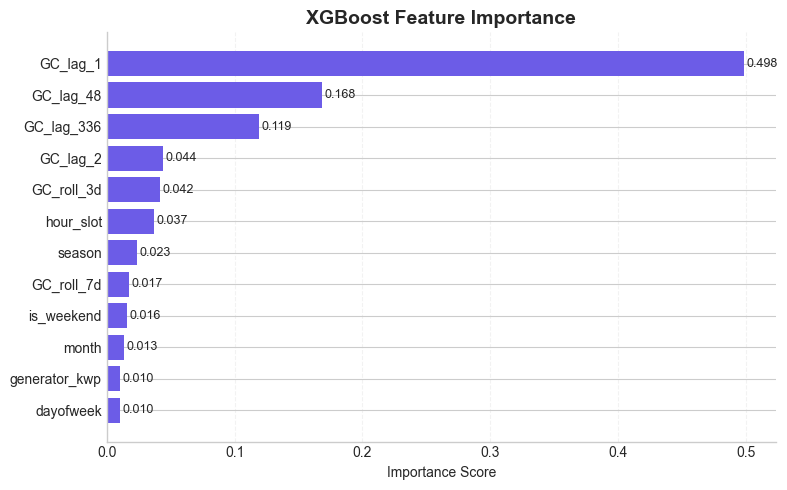

In [12]:
# Better XGBoost feature importance
imp_xgb = pd.Series(xgb.feature_importances_, index=present).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(imp_xgb.index[::-1], imp_xgb.values[::-1], color=CHART_COLORS["XGBoost"])
ax.set_title("XGBoost Feature Importance", fontsize=14, weight="bold")
ax.set_xlabel("Importance Score")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.25)

for i, v in enumerate(imp_xgb.values[::-1]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

final_plot("xgb_feature_importance.png")

## 5. Model 3 — LSTM (PyTorch)

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import os

SEQ_LEN     = 48
HIDDEN      = 64
LAYERS      = 2
DROPOUT     = 0.2
BATCH       = 512
EPOCHS      = 2
LR          = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Scale features
scaler  = StandardScaler()
Xtr_sc  = scaler.fit_transform(X_train)
Xte_sc  = scaler.transform(X_test)

# 🔥 IMPORTANT FIX: convert ONCE (not inside Dataset)
Xtr_tensor = torch.from_numpy(Xtr_sc).float()
ytr_tensor = torch.from_numpy(y_train).float()

Xte_tensor = torch.from_numpy(Xte_sc).float()
yte_tensor = torch.from_numpy(y_test).float()

Device: cuda


In [14]:
class SeqDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X = X
        self.y = y
        self.sl = seq_len

    def __len__(self):
        return len(self.y) - self.sl

    def __getitem__(self, i):
        return self.X[i:i+self.sl], self.y[i+self.sl]


class LSTMNet(nn.Module):
    def __init__(self, in_sz, hid, layers, drop):
        super().__init__()
        self.lstm = nn.LSTM(
            in_sz, hid, layers,
            batch_first=True,
            dropout=drop if layers > 1 else 0
        )
        self.fc = nn.Linear(hid, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


train_dl = DataLoader(
    SeqDataset(Xtr_tensor, ytr_tensor, SEQ_LEN),
    batch_size=BATCH,
    shuffle=True,
    pin_memory=True,
    num_workers=0
)

test_dl = DataLoader(
    SeqDataset(Xte_tensor, yte_tensor, SEQ_LEN),
    batch_size=BATCH,
    shuffle=False,
    pin_memory=True,
    num_workers=0
)

model = LSTMNet(len(present), HIDDEN, LAYERS, DROPOUT).to(device)

# 🔥 Optional but recommended (speed boost)
model = torch.compile(model)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

print(model)

OptimizedModule(
  (_orig_mod): LSTMNet(
    (lstm): LSTM(12, 64, num_layers=2, batch_first=True, dropout=0.2)
    (fc): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [15]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 Laptop GPU


In [16]:
import time

train_losses = []
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    ep_loss = 0.0

    for Xb, yb in train_dl:
        Xb = Xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        pred = model(Xb)
        loss = criterion(pred, yb)

        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        ep_loss += loss.detach().item() * Xb.size(0)

    ep_loss /= len(train_dl.dataset)
    train_losses.append(ep_loss)

    if epoch % 3 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  MSE: {ep_loss:.5f}")

# Save model
model_path = os.path.join(MODELS_DIR, "lstm.pt")
torch.save(model.state_dict(), model_path)

print(f"\n✅ Model saved at: {model_path}")
print(f"⏱️ Total time: {time.time() - start_time:.2f} sec")

Epoch   1/2  MSE: 0.13315

✅ Model saved at: D:/Minor Project/models\lstm.pt
⏱️ Total time: 384.53 sec


LSTM                  RMSE=0.3580  MAE=0.2347  R²=0.1058


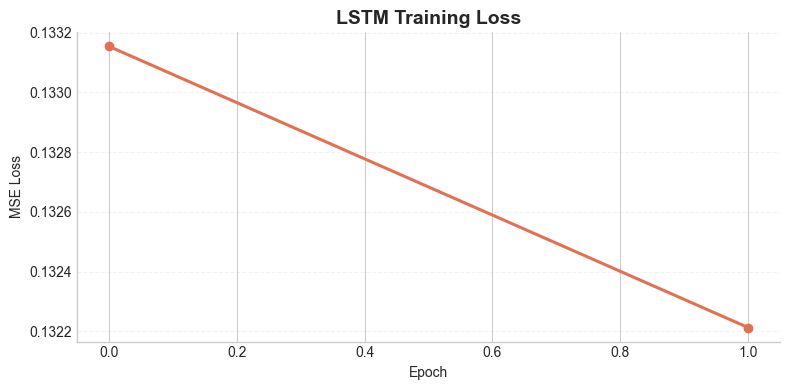

In [17]:
# Evaluate LSTM
model.eval()
preds, actuals = [], []
with torch.no_grad():
    for Xb, yb in test_dl:
        p = model(Xb.to(device)).cpu().numpy()
        preds.extend(p); actuals.extend(yb.numpy())

y_pred_lstm = np.array(preds)
y_true_lstm = np.array(actuals)
all_results.append(metrics(y_true_lstm, y_pred_lstm, "LSTM"))
all_preds["LSTM"] = y_pred_lstm

# Better LSTM loss
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, marker="o", linewidth=2.2, color=CHART_COLORS["LSTM"])
ax.set_title("LSTM Training Loss", fontsize=14, weight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)

final_plot("lstm_loss.png")

## 6. Final comparison

In [18]:
results_df = pd.DataFrame(all_results)

results_df = (
    results_df
    .drop_duplicates(subset="Model", keep="last")
    .set_index("Model")
    .loc[["Random Forest", "XGBoost", "LSTM"]]
)

results_df.to_csv(os.path.join(RESULTS_DIR, "model_comparison.csv"))
results_df

,RMSE,MAE,R2
Model,,,
Random Forest,0.2664,0.1418,0.5047
XGBoost,0.2632,0.1429,0.5166
LSTM,0.3580,0.2347,0.1058


In [19]:
results_df = pd.DataFrame(all_results).set_index("Model")
print("\n── Model Comparison ──────────────────────────")
print(results_df.to_string())
results_df.to_csv(os.path.join(RESULTS_DIR, "model_comparison.csv"))



── Model Comparison ──────────────────────────
                 RMSE     MAE      R2
Model                                
Random Forest  0.2664  0.1418  0.5047
XGBoost        0.2632  0.1429  0.5166
LSTM           0.3580  0.2347  0.1058


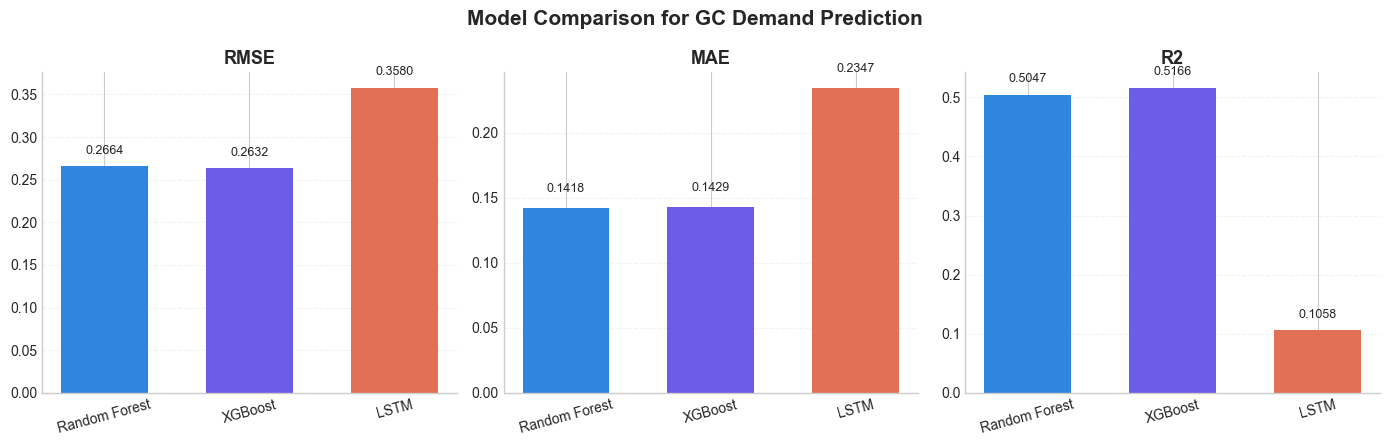

In [20]:
# Bar chart — RMSE, MAE, R²
colors = {"Random Forest":"#378ADD","XGBoost":"#7F77DD","LSTM":"#D85A30"}
bar_c  = [colors[m] for m in results_df.index]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=[CHART_COLORS[m] for m in vals.index], width=0.6)
    ax.set_title(metric, fontsize=13, weight="bold")
    ax.tick_params(axis="x", rotation=15)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.25)

    y_pad = max(abs(vals.max()) * 0.03, 0.01)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + y_pad, f"{v:.4f}",
                ha="center", va="bottom", fontsize=9)

fig.suptitle("Model Comparison for GC Demand Prediction", fontsize=15, weight="bold")
final_plot("model_comparison.png")

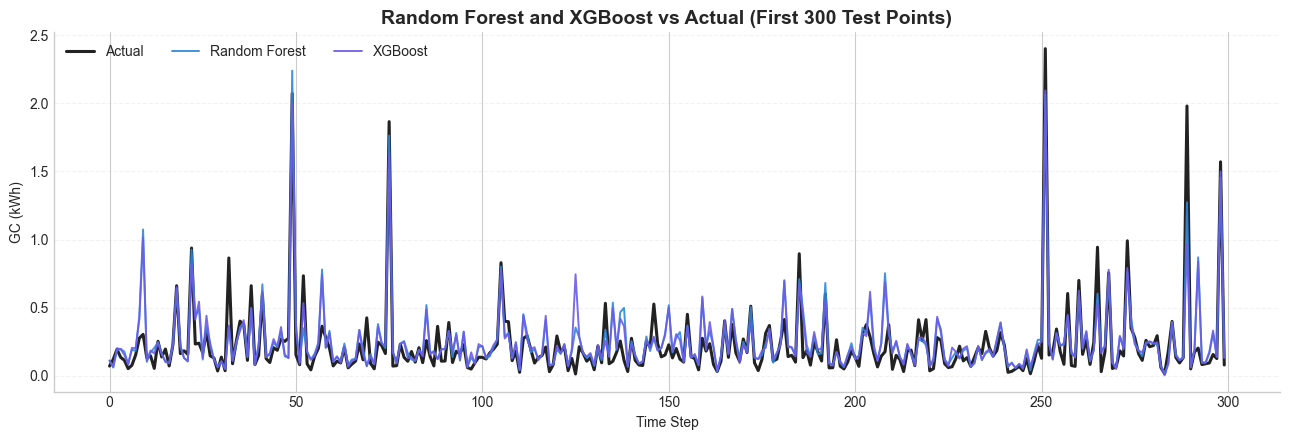

In [21]:
# RF + XGB overlay
N = 300
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(y_test[:N], label="Actual", color=CHART_COLORS["Actual"], lw=2.2)

for name in ["Random Forest", "XGBoost"]:
    ax.plot(all_preds[name][:N], label=name, color=CHART_COLORS[name], lw=1.4, alpha=0.9)

ax.set_title("Random Forest and XGBoost vs Actual (First 300 Test Points)", fontsize=14, weight="bold")
ax.set_ylabel("GC (kWh)")
ax.set_xlabel("Time Step")
ax.legend(frameon=False, ncol=3)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.25)

final_plot("rf_xgb_overlay.png")

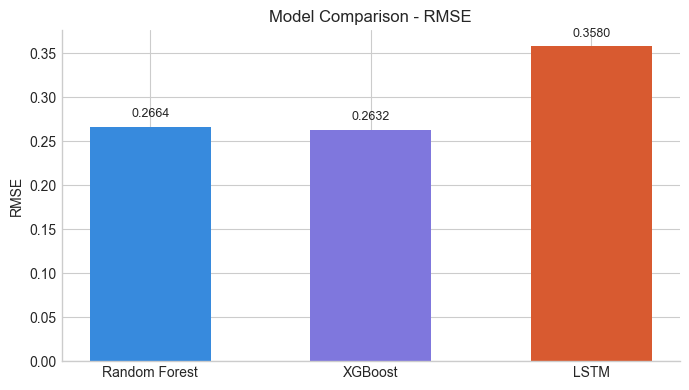

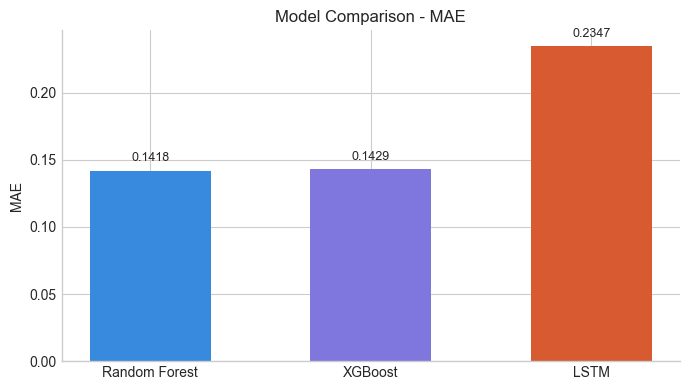

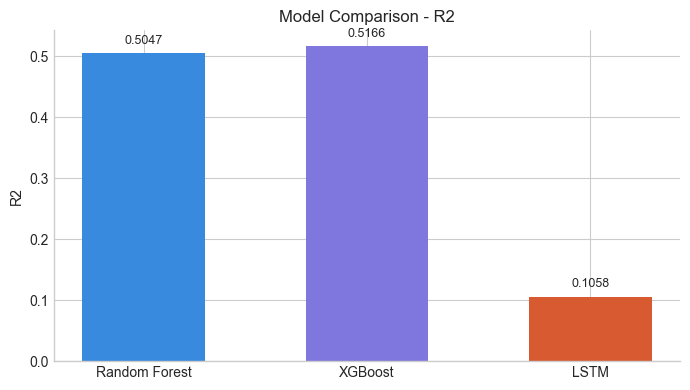

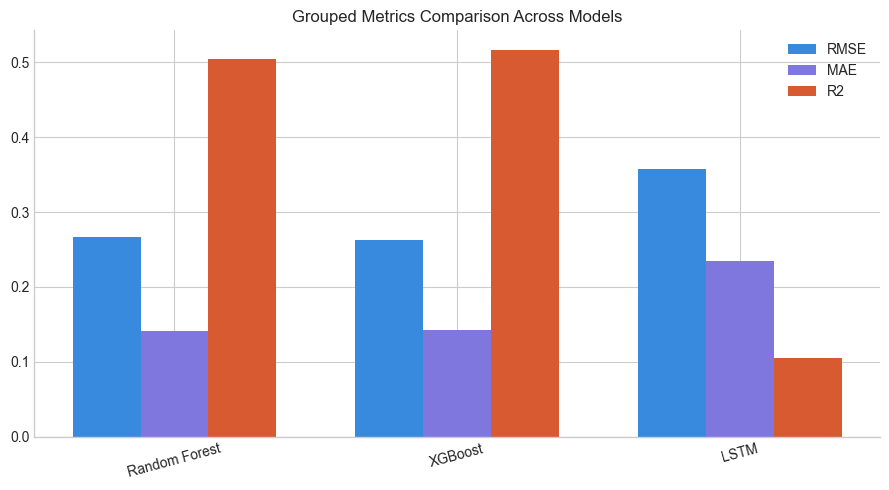

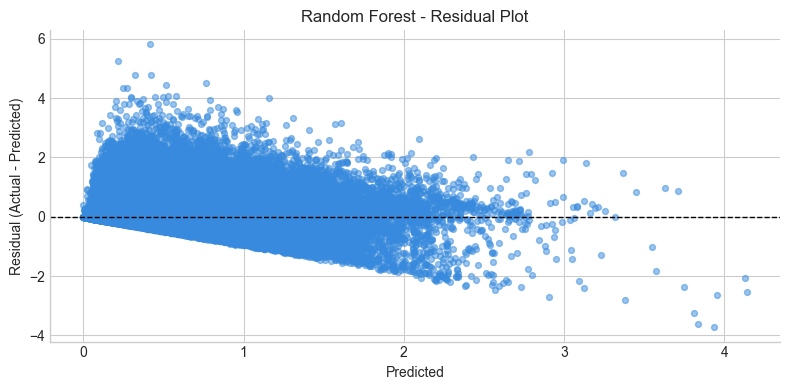

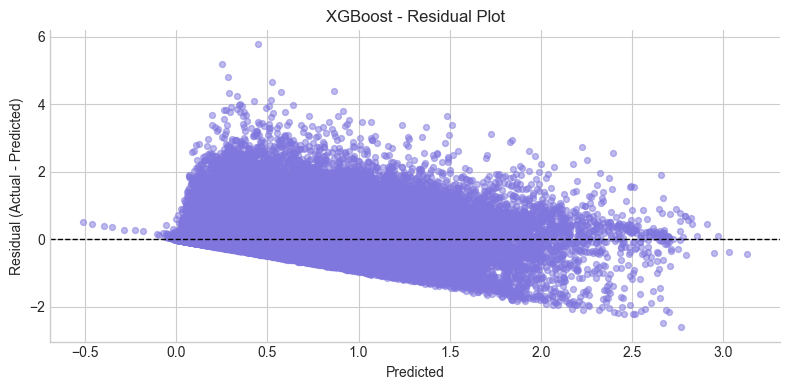

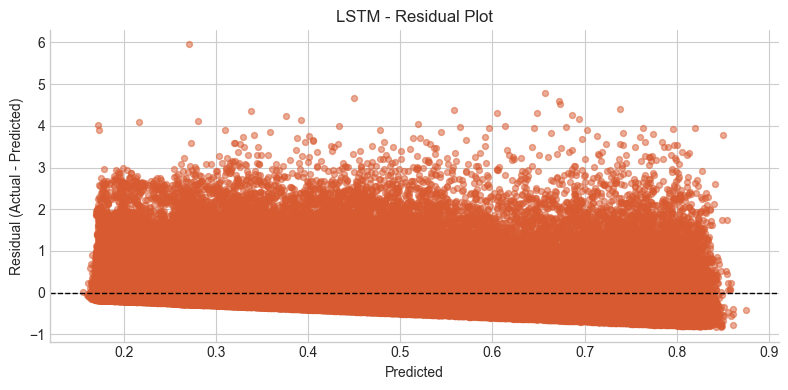

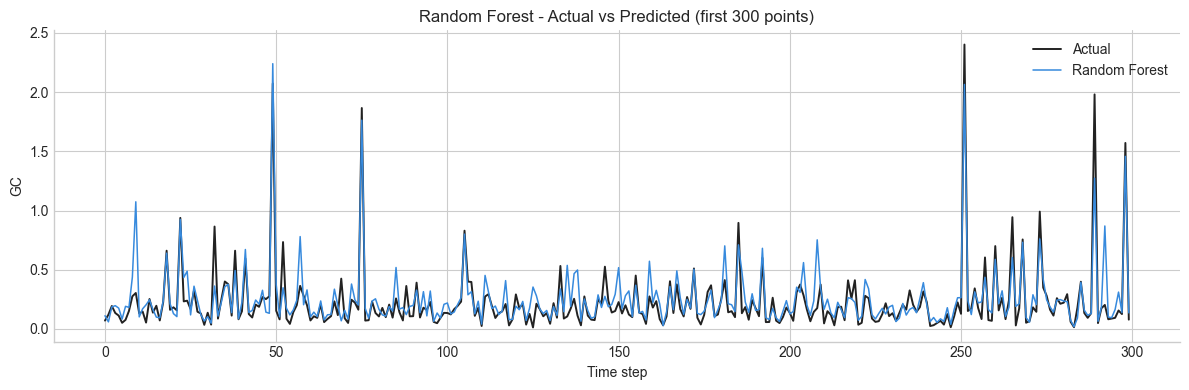

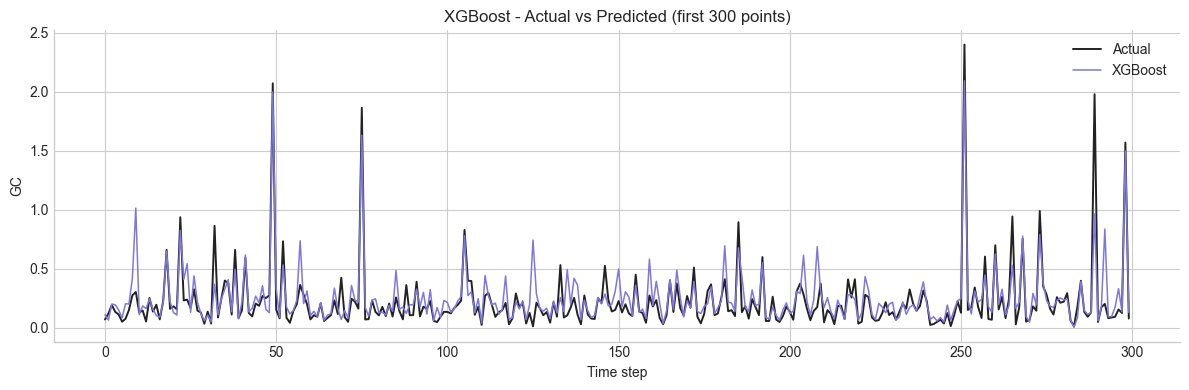

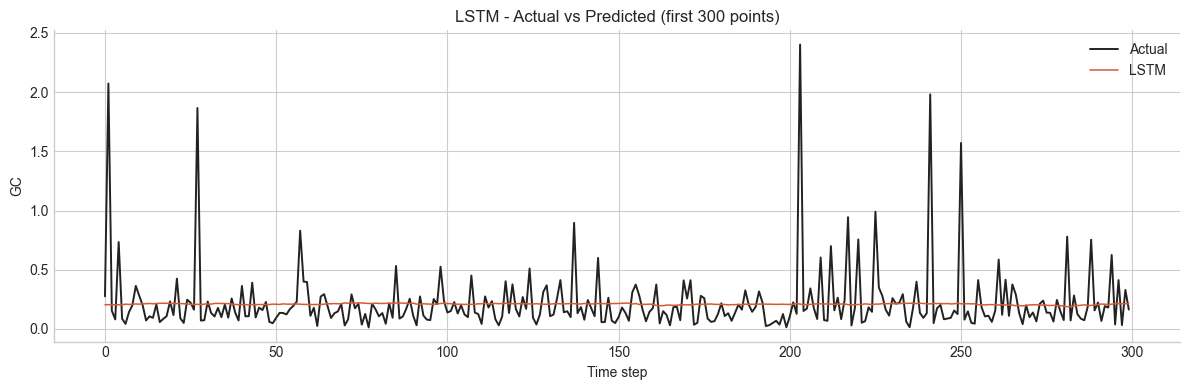

All additional charts saved in: D:/Minor Project/results


In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs(RESULTS_DIR, exist_ok=True)

colors = {"Random Forest":"#378ADD", "XGBoost":"#7F77DD", "LSTM":"#D85A30"}

# If not already indexed by model name
plot_df = results_df.copy()
if "Model" in plot_df.columns:
    plot_df = plot_df.set_index("Model")

# 1) Separate bar charts for each metric
for metric in ["RMSE", "MAE", "R2"]:
    fig, ax = plt.subplots(figsize=(7, 4))
    vals = plot_df[metric]
    bars = ax.bar(plot_df.index, vals, color=[colors[m] for m in plot_df.index], width=0.55)

    ax.set_title(f"Model Comparison - {metric}")
    ax.set_ylabel(metric)
    ax.spines[["top", "right"]].set_visible(False)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + vals.max()*0.02,
                f"{v:.4f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{metric.lower()}_bar_chart.png"), dpi=150, bbox_inches="tight")
    plt.show()

# 2) Grouped bar chart for all metrics
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(plot_df.index))
w = 0.24

ax.bar(x - w, plot_df["RMSE"], width=w, label="RMSE", color="#378ADD")
ax.bar(x,      plot_df["MAE"],  width=w, label="MAE",  color="#7F77DD")
ax.bar(x + w,  plot_df["R2"],   width=w, label="R2",   color="#D85A30")

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=15)
ax.set_title("Grouped Metrics Comparison Across Models")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "grouped_metrics_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

# 3) Residual plots
# RF and XGB use y_test in your notebook; LSTM uses y_true_lstm
truth_map = {
    "Random Forest": y_test,
    "XGBoost": y_test,
    "LSTM": y_true_lstm
}

for model_name, pred in all_preds.items():
    y_true = np.array(truth_map[model_name])
    pred = np.array(pred)
    n = min(len(y_true), len(pred))
    residuals = y_true[:n] - pred[:n]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(pred[:n], residuals, alpha=0.5, s=18, color=colors[model_name])
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{model_name} - Residual Plot")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{model_name.lower().replace(' ', '_')}_residual_plot.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

# 4) Actual vs predicted separately for each model
N = 300

for model_name, pred in all_preds.items():
    y_true = np.array(truth_map[model_name])
    pred = np.array(pred)
    n = min(len(y_true), len(pred), N)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(y_true[:n], label="Actual", color="#222", linewidth=1.4)
    ax.plot(pred[:n], label=model_name, color=colors[model_name], linewidth=1.1)
    ax.set_title(f"{model_name} - Actual vs Predicted (first {n} points)")
    ax.set_xlabel("Time step")
    ax.set_ylabel("GC")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{model_name.lower().replace(' ', '_')}_actual_vs_predicted.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

print("All additional charts saved in:", RESULTS_DIR)

In [22]:
plt.savefig(os.path.join(RESULTS_DIR, "chart_name.png"), dpi=200, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>